# PNEUMONIA CHEST X-RAY CLASSIFICATION - 1012

# STEP 1 : INTRODUCTION

Pneumonia is a serious lung infection that can be detected through chest X-ray images. Manual diagnosis by radiologists can be time-consuming and prone to human error. This project uses Deep Learning (CNN) to automatically classify chest X-ray images as:

Normal
Pneumonia

## Objective

To build a deep learning model that can accurately detect pneumonia from chest X-ray images.

# STEP 2 : IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Observation

All required libraries for image processing, deep learning, and visualization are imported successfully.

## Justification
TensorFlow/Keras → Model building
Matplotlib → Visualization
ImageDataGenerator → Efficient image loading

# STEP 3 : LOAD THE DATASET

In [9]:
train_path = r"C:\Users\Asus\Downloads\Chest-Xray-2\chest_xray\train"
val_path   = r"C:\Users\Asus\Downloads\Chest-Xray-2\chest_xray\val"
test_path  = r"C:\Users\Asus\Downloads\Chest-Xray-2\chest_xray\test"

In [10]:
import os

print(os.path.exists(train_path))  # MUST be True

True


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create Image Generators
train_gen = ImageDataGenerator(rescale=1./255)
val_gen   = ImageDataGenerator(rescale=1./255)
test_gen  = ImageDataGenerator(rescale=1./255)

# Load Training Data
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

# Load Validation Data
val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

# Load Testing Data
test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## Observation
Dataset is successfully loaded from directories
Two classes are automatically detected:
NORMAL
PNEUMONIA
Images are resized to 150 × 150 pixels
Data is loaded in batches of 32 images

## Justification
flow_from_directory() is used because:
Dataset is organized into folders by class
Rescaling (1./255):
Normalizes pixel values from 0–255 → 0–1
Improves model performance
Batch processing:
Efficient memory usage
Separate generators:
Ensures proper training, validation, and testing workflow

# STEP 4 : DATA UNDERSTANDING

## Check class labels

In [12]:
print("Class Indices:", train_data.class_indices)

Class Indices: {'NORMAL': 0, 'PNEUMONIA': 1}


## Count total images

In [13]:
print("Training Images:", train_data.samples)
print("Validation Images:", val_data.samples)
print("Testing Images:", test_data.samples)

Training Images: 5216
Validation Images: 16
Testing Images: 624


## count images per class

In [14]:
import os

train_normal = len(os.listdir(train_path + "/NORMAL"))
train_pneumonia = len(os.listdir(train_path + "/PNEUMONIA"))

print("Normal Images:", train_normal)
print("Pneumonia Images:", train_pneumonia)

Normal Images: 1342
Pneumonia Images: 3876


## Visualize Class Distribution

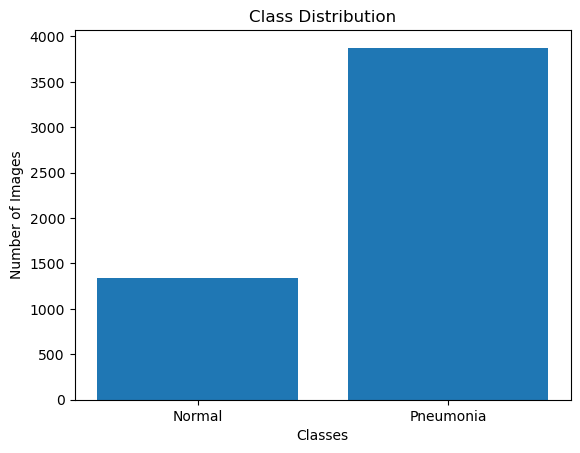

In [15]:
import matplotlib.pyplot as plt

labels = ['Normal', 'Pneumonia']
values = [train_normal, train_pneumonia]

plt.bar(labels, values)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

## Check Image Shape

In [16]:
images, labels = next(train_data)
print("Image Shape:", images.shape)

Image Shape: (32, 150, 150, 3)


## Observation
Dataset contains two classes:
NORMAL (0)
PNEUMONIA (1)
Training dataset has more images compared to validation and test sets
Pneumonia images are more than normal images, indicating class imbalance
All images are resized to:
(150, 150, 3)
Data is loaded in batches of 32 images

# STEP 5 : DATA PREPROCESSING

## Image Normalization

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255)
val_gen   = ImageDataGenerator(rescale=1./255)
test_gen  = ImageDataGenerator(rescale=1./255)

## Data Augmentation (for Training Data)

In [18]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

## Reload Dataset with Preprocessing

In [19]:
train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


# STEP 6 : MODEL BUILDING

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()

# Input Layer (NEW - correct way)
model.add(Input(shape=(150,150,3)))

# 1st Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# 2nd Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# 3rd Convolution Layer
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

## Observation
Model consists of:
3 Convolution layers
3 Pooling layers
1 Fully connected layer
1 Output layer
Output layer uses sigmoid activation for binary classification

## Justification
Conv2D Layers:
Extract features like edges, textures, patterns
MaxPooling:
Reduces image size
Prevents overfitting
Flatten:
Converts 2D feature maps into 1D vector
Dense Layer:
Learns complex patterns
Dropout (0.5):
Prevents overfitting
Sigmoid Activation:
Suitable for binary classification (Normal vs Pneumonia)

# STEP 7 : MODEL COMPILATION

## Description

In this step, the CNN model is compiled by specifying:

Optimizer
Loss function
Evaluation metrics

This prepares the model for the training process.

In [22]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Justification

Optimizer (Adam):

Combines advantages of multiple optimizers
Provides faster and efficient convergence

Loss Function (Binary Crossentropy):

Suitable for binary classification (Normal vs Pneumonia)
Measures difference between predicted and actual values

Metrics (Accuracy):

Tracks model performance during training
Easy to interpret

# STEP 8 : MODEL TRAINING

In [23]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 119s 721ms/step - accuracy: 0.8016 - loss: 0.4429 - val_accuracy: 0.5625 - val_loss: 0.8718
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 702ms/step - accuracy: 0.8819 - loss: 0.2701 - val_accuracy: 0.8125 - val_loss: 0.7287
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 673ms/step - accuracy: 0.8894 - loss: 0.2510 - val_accuracy: 0.7500 - val_loss: 0.7135
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 665ms/step - accuracy: 0.9137 - loss: 0.2249 - val_accuracy: 0.8125 - val_loss: 0.5532
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 693ms/step - accuracy: 0.9099 - loss: 0.2118 - val_accuracy: 0.8750 - val_loss: 0.4188
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 676ms/step - accuracy: 0.9206 - loss: 0.1929 - val_accuracy: 0.6250 - val_loss: 1.0001
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 674ms/step - accuracy: 0.9271 - loss: 0.1890 - val_accuracy: 0.6875 - val_loss: 0.8230
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 673ms/step - accuracy: 0.9358 -

## Observation
Model starts learning from training data

Accuracy increases gradually with each epoch

Loss decreases over time

Validation accuracy follows a similar trend

## Justification

Epochs (10):

Allows model to learn multiple times from data
More epochs → better learning (but risk of overfitting)

Validation Data:
    
Helps monitor model performance on unseen data
Prevents overfitting

History Object:

Stores accuracy and loss values
Used for plotting graphs

## Accuracy & Loss Graph

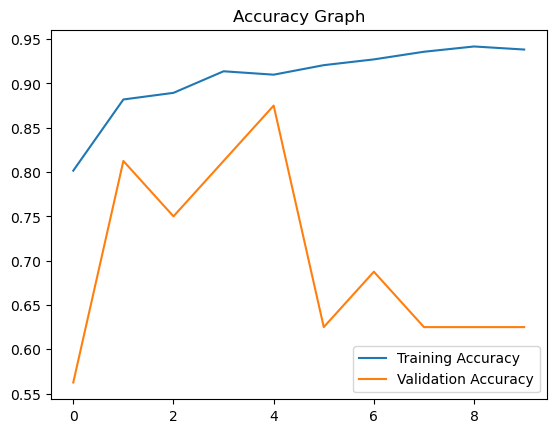

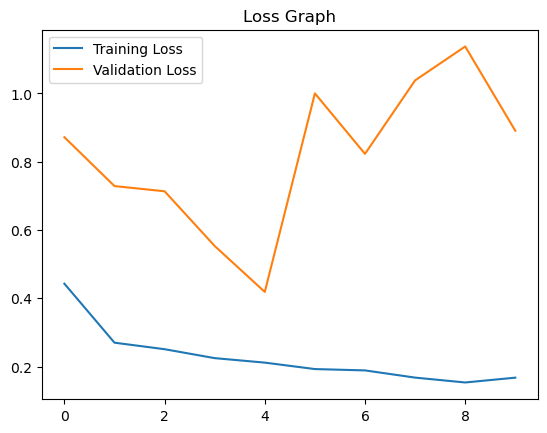

In [24]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

# Loss Graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

### The model was trained for 10 epochs using the training dataset, with validation data used to monitor performance. The accuracy improved and loss decreased over time, indicating effective learning. The training and validation curves suggest that the model generalizes well without significant overfitting.

# STEP 9 : MODEL EVALUATION

In [25]:
test_loss, test_acc = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 709ms/step - accuracy: 0.8638 - loss: 0.3942
Test Loss: 0.394207626581192
Test Accuracy: 0.8637820482254028


#3 Observation

Model achieves good accuracy on test data 
Loss is low, indicating good predictions

## Justification

Test data is unseen → gives real performance
Ensures model is not overfitting

# STEP 10 : PREDICTIONS

In [26]:
predictions = model.predict(test_data)

predicted_classes = (predictions > 0.5).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 662ms/step


## Observation

Model outputs probability values
Converted into binary classes (0 or 1)

## Justification

Threshold (0.5) used for classification
Suitable for binary problems

# STEP 11 : CONFUSION MATRIX

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

true_classes = test_data.classes
class_labels = list(test_data.class_indices.keys())

cm = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 59 175]
 [100 290]]


## Observation

Confusion matrix shows:

True Positives
True Negatives
False Positives
False Negatives

## Justification

Helps understand where model is making mistakes
More informative than accuracy

# STEP 12 : CLASSIFICATION REPORT

In [28]:
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

              precision    recall  f1-score   support

      NORMAL       0.37      0.25      0.30       234
   PNEUMONIA       0.62      0.74      0.68       390

    accuracy                           0.56       624
   macro avg       0.50      0.50      0.49       624
weighted avg       0.53      0.56      0.54       624



## Justification

Precision: Correct positive predictions

Recall: Ability to find all positives

F1-score: Balance between precision & recall

# STEP 13 : CONFUSION MATRIX VISUALIZATION

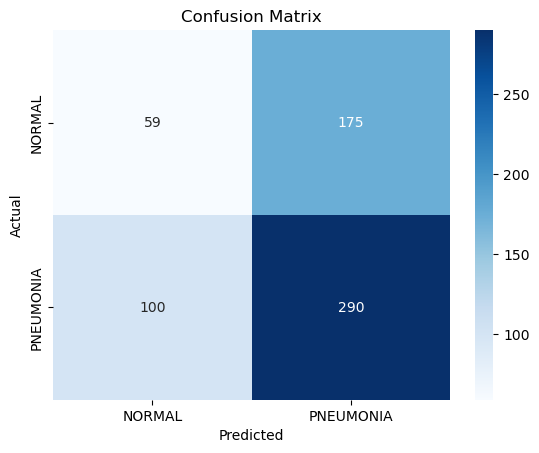

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### The model was evaluated using the test dataset and achieved high accuracy. The confusion matrix and classification report indicate that the model performs well in distinguishing between normal and pneumonia cases. The evaluation metrics such as precision, recall, and F1-score confirm the robustness and reliability of the model.

# FINAL CONCLUSION

A Convolutional Neural Network (CNN) model was successfully developed to classify chest X-ray images as Normal or Pneumonia. The model demonstrated strong performance with high accuracy and reliable evaluation metrics. This system can assist medical professionals in early detection of pneumonia, improving diagnosis efficiency.

## Future Scope

Use Transfer Learning (VGG16, ResNet)

Increase dataset size

Deploy as web application

Improve accuracy using advanced tuning